 # Predicting the Bowling Order in IPL Using Multiple Regression





 ## 1. Load Data and Calculate Global Stats



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv("deliveries.csv")
df["is_wicket"] = df["is_wicket"].fillna(0).astype(int)

bowler_stats = df.groupby("bowler").agg(
    runs_conceded=("total_runs", "sum"),
    wickets_taken=("is_wicket", "sum"),
    balls_bowled=("ball", "count")
).reset_index()

bowler_stats["overs_bowled"] = bowler_stats["balls_bowled"] / 6
bowler_stats["economy_rate"] = bowler_stats["runs_conceded"] / bowler_stats["overs_bowled"]

bowler_stats.head()

,bowler,runs_conceded,wickets_taken,balls_bowled,overs_bowled,economy_rate
0,A Ashish Reddy,400,19,270,45.000000,8.888889
1,A Badoni,37,2,25,4.166667,8.880000
2,A Chandila,245,11,234,39.000000,6.282051
3,A Choudhary,144,5,108,18.000000,8.000000
4,A Dananjaya,47,0,25,4.166667,11.280000


 ## 2. Isolate a Team & Define the Target Variable



In [3]:
team_name = "Royal Challengers Bangalore"
team_df = df[df["bowling_team"] == team_name].copy()

avg_overs = team_df.groupby("bowler")["over"].mean().reset_index()
avg_overs.rename(columns={"over": "historical_avg_over"}, inplace=True)

model_df = bowler_stats.merge(avg_overs, on="bowler")

model_df = model_df[model_df["balls_bowled"] >= 60].copy()

print(f"Total regular bowlers found for {team_name}: {len(model_df)}")
model_df.head()

Total regular bowlers found for Royal Challengers Bangalore: 88


,bowler,runs_conceded,wickets_taken,balls_bowled,overs_bowled,economy_rate,historical_avg_over
0,A Choudhary,144,5,108,18.000000,8.000000,8.277778
1,A Kumble,1089,49,983,163.833333,6.646999,9.853510
2,A Mithun,477,8,312,52.000000,9.173077,10.496795
3,A Zampa,562,30,425,70.833333,7.934118,10.089552
6,AB Dinda,2103,82,1589,264.833333,7.940843,9.771930


 ## 3. Train the Multiple Regression Model



In [4]:
X = model_df[["economy_rate", "wickets_taken", "balls_bowled"]]
y = model_df["historical_avg_over"]

model = LinearRegression()
model.fit(X, y)

model_df["predicted_avg_over"] = model.predict(X) 
print(model_df)

model_df = model_df.sort_values("predicted_avg_over")

all_bowlers = model_df["bowler"].tolist()
print("Available bowlers for the innings:", len(all_bowlers))

                bowler  runs_conceded  wickets_taken  balls_bowled  \
0          A Choudhary            144              5           108   
1             A Kumble           1089             49           983   
2             A Mithun            477              8           312   
3              A Zampa            562             30           425   
6             AB Dinda           2103             82          1589   
..                 ...            ...            ...           ...   
101         WD Parnell            968             40           758   
102  Washington Sundar           1335             39          1064   
103          YS Chahal           4681            213          3628   
104       Yuvraj Singh           1091             39           882   
105             Z Khan           2860            119          2276   

     overs_bowled  economy_rate  historical_avg_over  predicted_avg_over  
0       18.000000      8.000000             8.277778            8.853312  
1      16

 ## 4. Prediction Pipeline



In [8]:
print(model_df[model_df["bowler"] == "M Muralitharan"][["bowler", "predicted_avg_over"]])

            bowler  predicted_avg_over
55  M Muralitharan            8.254676


In [10]:
overs_schedule = []
bowler_overs_count = {b: 0 for b in all_bowlers}

for current_over in range(20):
    best_bowler = None
    min_diff = float('inf')
    
    for bowler in all_bowlers:
        if bowler_overs_count[bowler] < 4:
            
            if current_over == 0 or overs_schedule[-1] != bowler:
                
                pred_over = model_df[model_df["bowler"] == bowler]["predicted_avg_over"].iloc[0]
                diff = abs(pred_over - current_over)
                
                if diff < min_diff:
                    min_diff = diff
                    best_bowler = bowler
    
    if best_bowler is None:
        for bowler in all_bowlers:
            if bowler_overs_count[bowler] < 4:
                best_bowler = bowler
                break
                
    overs_schedule.append(best_bowler)
    if best_bowler is not None:
        bowler_overs_count[best_bowler] = bowler_overs_count.get(best_bowler, 0) + 1

predicted_innings = pd.DataFrame({
    "Over": range(1, 21),
    "Predicted_Bowler": overs_schedule
})

predicted_innings

,Over,Predicted_Bowler
0,1,M Muralitharan
1,2,M Kartik
2,3,M Muralitharan
3,4,M Kartik
4,5,M Muralitharan
5,6,M Kartik
6,7,M Muralitharan
7,8,M Kartik
8,9,P Kumar
9,10,AN Ahmed


 ## 5. Visualization



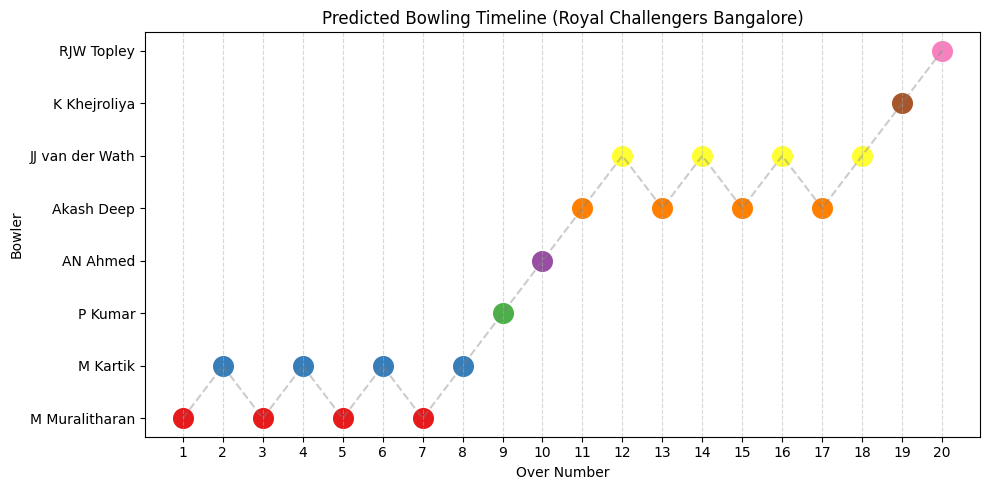

In [7]:
plt.figure(figsize=(10, 5))

unique_bowlers = predicted_innings["Predicted_Bowler"].dropna().unique()
colors = sns.color_palette("Set1", len(unique_bowlers))
color_map = dict(zip(unique_bowlers, colors))

for _, row in predicted_innings.iterrows():
    bowler_name = row["Predicted_Bowler"]
    if pd.isna(bowler_name):
        continue
    plt.scatter(row["Over"], bowler_name, color=color_map.get(bowler_name, "gray"), s=200)

valid_innings = predicted_innings.dropna(subset=["Predicted_Bowler"])
plt.plot(valid_innings["Over"], valid_innings["Predicted_Bowler"], linestyle="--", alpha=0.4, color="gray")

plt.title(f"Predicted Bowling Timeline ({team_name})")
plt.xlabel("Over Number")
plt.ylabel("Bowler")
plt.xticks(range(1, 21))
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()